# Q-learning(0) e SARSA(0) no Blackjack

Experimento independente no `Blackjack-v1`, baseado nos exemplos da disciplina.

Serão comparados:

- **Q-learning(0)** — TD, off-policy;
- **SARSA(0)** — TD, on-policy.

Também será estudado o efeito da taxa de aprendizado $\alpha$ e, ao final, os resultados serão comparados ao Monte Carlo Control do experimento anterior.


## 1. Introdução

O objetivo é comparar Q-learning e SARSA sob as mesmas condições experimentais.

Diferentemente de Monte Carlo, os dois métodos atualizam $Q(s,a)$ a cada transição, usando **bootstrapping**.

### Hipóteses

- ambos devem aprender políticas superiores à política fixa;
- as políticas finais devem ser semelhantes, mas não necessariamente idênticas;
- Q-learning e SARSA podem apresentar trajetórias de aprendizado diferentes devido à diferença entre off-policy e on-policy;
- $\alpha$ muito pequeno pode tornar o aprendizado lento;
- $\alpha$ muito alto pode aumentar a variabilidade das atualizações.


## 2. Fundamentação teórica

### 2.1 Temporal Difference

$$
\delta_t = R_{t+1} + \gamma \hat Q_{t+1} - Q(S_t,A_t)
$$

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha \delta_t
$$

### 2.2 Q-learning(0)

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma \max_a Q(S_{t+1},a)
-
Q(S_t,A_t)
\right]
$$

Q-learning é **off-policy**: o alvo considera a melhor ação estimada no próximo estado.

### 2.3 SARSA(0)

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\right]
$$

SARSA é **on-policy**: o alvo utiliza a ação realmente escolhida pela política corrente.

### 2.4 Comparação

| Algoritmo | Tipo | Alvo TD |
|---|---|---|
| SARSA(0) | On-policy | $Q(S_{t+1},A_{t+1})$ |
| Q-learning(0) | Off-policy | $\max_a Q(S_{t+1},a)$ |


## 3. Ambiente Blackjack-v1

Configuração:

```python
Blackjack-v1
natural=False
sab=False
```

Estado:

$$
(\text{soma do jogador},\ \text{carta visível do dealer},\ \text{ás utilizável})
$$

Ações:

- `0 = stick`
- `1 = hit`

Recompensas:

- vitória: `+1`;
- empate: `0`;
- derrota: `-1`.


## 4. Configuração experimental


In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

%matplotlib inline

BASE_SEED = 42
SEEDS = [42, 43, 44, 45, 46]

N_EPISODES = 500_000
EVAL_EPISODES = 10_000

LEARNING_RATE = 0.01
LEARNING_RATES = [0.001, 0.01, 0.1]

GAMMA = 0.95

START_EPSILON = 1.0
FINAL_EPSILON = 0.1

# Mantém a forma usada nos notebooks-base da disciplina.
EPSILON_DECAY = START_EPSILON / (N_EPISODES / 2)

BLOCK_SIZE = 5_000

print("Seeds:", SEEDS)
print("Episódios:", N_EPISODES)
print("Alpha principal:", LEARNING_RATE)
print("Alphas:", LEARNING_RATES)


Seeds: [42, 43, 44, 45, 46]
Episódios: 500000
Alpha principal: 0.01
Alphas: [0.001, 0.01, 0.1]


### 4.1 Desenho experimental

**Experimento A — comparação principal**

- Q-learning × SARSA;
- 500.000 episódios;
- $\alpha=0.01$;
- $\gamma=0.95$;
- 5 seeds.

**Experimento B — efeito de $\alpha$**

- $\alpha \in \{0.001, 0.01, 0.1\}$;
- 500.000 episódios;
- 5 seeds;
- os resultados de $\alpha=0.01$ do Experimento A serão reutilizados.


## 5. Funções comuns


In [2]:
def make_env():
    return gym.make(
        "Blackjack-v1",
        natural=False,
        sab=False
    )


def block_mean(values, block_size=5_000):
    values = np.asarray(values, dtype=float)
    usable = (len(values) // block_size) * block_size
    values = values[:usable]
    return values.reshape(-1, block_size).mean(axis=1)


def evaluate_q_table(q_values, episodes=10_000, seed=100_000):
    env = make_env()
    env.reset(seed=seed)

    rewards = []
    lengths = []

    for _ in range(episodes):
        state, _ = env.reset()
        terminated = truncated = False
        total_reward = 0.0
        steps = 0

        while not (terminated or truncated):
            values = q_values.get(tuple(state), np.zeros(env.action_space.n))
            action = int(np.argmax(values))

            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1

        rewards.append(total_reward)
        lengths.append(steps)

    env.close()
    rewards = np.asarray(rewards)

    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "win_rate": float(np.mean(rewards == 1)),
        "draw_rate": float(np.mean(rewards == 0)),
        "loss_rate": float(np.mean(rewards == -1)),
        "mean_length": float(np.mean(lengths)),
    }


## 6. Q-learning(0)


In [3]:
class QLearningAgent:
    def __init__(
        self, n_actions, learning_rate, initial_epsilon,
        epsilon_decay, final_epsilon, discount_factor=0.95, seed=42
    ):
        self.n_actions = n_actions
        self.q_values = defaultdict(lambda: np.zeros(n_actions, dtype=float))
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.rng = np.random.default_rng(seed)

    def get_action(self, obs):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))
        return int(np.argmax(self.q_values[tuple(obs)]))

    def update(self, obs, action, reward, terminated, next_obs):
        obs = tuple(obs)
        next_obs = tuple(next_obs)

        future_q = 0.0 if terminated else np.max(self.q_values[next_obs])

        td_error = (
            reward
            + self.discount_factor * future_q
            - self.q_values[obs][action]
        )

        self.q_values[obs][action] += self.learning_rate * td_error
        return float(td_error)

    def decay_epsilon(self):
        self.epsilon = max(
            self.final_epsilon,
            self.epsilon - self.epsilon_decay
        )


## 7. SARSA(0)


In [4]:
class SARSAAgent:
    def __init__(
        self, n_actions, learning_rate, initial_epsilon,
        epsilon_decay, final_epsilon, discount_factor=0.95, seed=42
    ):
        self.n_actions = n_actions
        self.q_values = defaultdict(lambda: np.zeros(n_actions, dtype=float))
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.rng = np.random.default_rng(seed)

    def get_action(self, obs):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))
        return int(np.argmax(self.q_values[tuple(obs)]))

    def update(self, obs, action, reward, terminated, next_obs, next_action):
        obs = tuple(obs)
        next_obs = tuple(next_obs)

        future_q = (
            0.0
            if terminated
            else self.q_values[next_obs][next_action]
        )

        td_error = (
            reward
            + self.discount_factor * future_q
            - self.q_values[obs][action]
        )

        self.q_values[obs][action] += self.learning_rate * td_error
        return float(td_error)

    def decay_epsilon(self):
        self.epsilon = max(
            self.final_epsilon,
            self.epsilon - self.epsilon_decay
        )


## 8. Treinamento comum

Para cada episódio são registrados:

- recompensa;
- comprimento do episódio;
- erro TD absoluto médio.


In [5]:
def train_agent(
    algorithm, num_episodes, learning_rate, gamma,
    start_epsilon, final_epsilon, epsilon_decay, seed
):
    env = make_env()
    env.reset(seed=seed)

    n_actions = env.action_space.n

    AgentClass = QLearningAgent if algorithm == "Q-learning" else SARSAAgent

    agent = AgentClass(
        n_actions=n_actions,
        learning_rate=learning_rate,
        initial_epsilon=start_epsilon,
        epsilon_decay=epsilon_decay,
        final_epsilon=final_epsilon,
        discount_factor=gamma,
        seed=seed
    )

    rewards = np.zeros(num_episodes, dtype=np.float32)
    lengths = np.zeros(num_episodes, dtype=np.int16)
    td_errors = np.zeros(num_episodes, dtype=np.float32)

    for episode in range(num_episodes):
        state, _ = env.reset()
        terminated = truncated = False
        total_reward = 0.0
        steps = 0
        episode_errors = []

        if algorithm == "SARSA":
            action = agent.get_action(state)

        while not (terminated or truncated):
            if algorithm == "Q-learning":
                action = agent.get_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)

            if algorithm == "Q-learning":
                td = agent.update(
                    state, action, reward, terminated, next_state
                )
            else:
                next_action = (
                    0 if terminated else agent.get_action(next_state)
                )

                td = agent.update(
                    state, action, reward, terminated, next_state, next_action
                )

                action = next_action

            episode_errors.append(abs(td))
            total_reward += reward
            steps += 1
            state = next_state

        rewards[episode] = total_reward
        lengths[episode] = steps
        td_errors[episode] = np.mean(episode_errors) if episode_errors else 0.0

        agent.decay_epsilon()

    env.close()

    return {
        "algorithm": algorithm,
        "seed": seed,
        "learning_rate": learning_rate,
        "q_values": {
            state: values.copy()
            for state, values in agent.q_values.items()
        },
        "rewards": rewards,
        "lengths": lengths,
        "td_errors": td_errors,
        "final_epsilon": agent.epsilon,
    }


## 9. Experimento A — comparação principal


In [6]:
main_results = []

for algorithm in ["Q-learning", "SARSA"]:
    for seed in SEEDS:
        print(f"Treinando {algorithm} — seed={seed}")

        result = train_agent(
            algorithm=algorithm,
            num_episodes=N_EPISODES,
            learning_rate=LEARNING_RATE,
            gamma=GAMMA,
            start_epsilon=START_EPSILON,
            final_epsilon=FINAL_EPSILON,
            epsilon_decay=EPSILON_DECAY,
            seed=seed
        )

        result["evaluation"] = evaluate_q_table(
            result["q_values"],
            episodes=EVAL_EPISODES,
            seed=100_000 + seed
        )

        main_results.append(result)

print("Experimento A concluído.")


Treinando Q-learning — seed=42
Treinando Q-learning — seed=43
Treinando Q-learning — seed=44
Treinando Q-learning — seed=45
Treinando Q-learning — seed=46
Treinando SARSA — seed=42
Treinando SARSA — seed=43
Treinando SARSA — seed=44
Treinando SARSA — seed=45
Treinando SARSA — seed=46
Experimento A concluído.


### 9.1 Curvas de treinamento


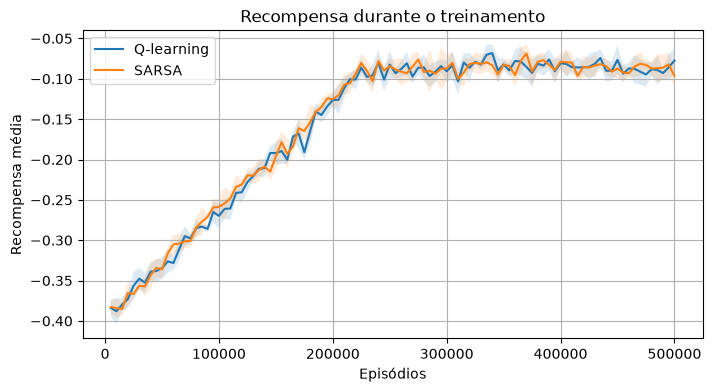

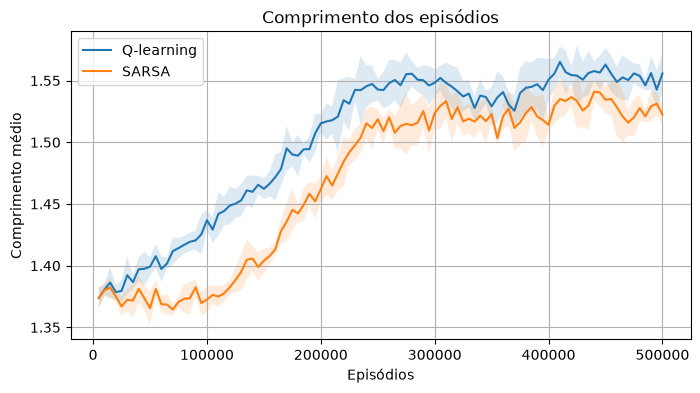

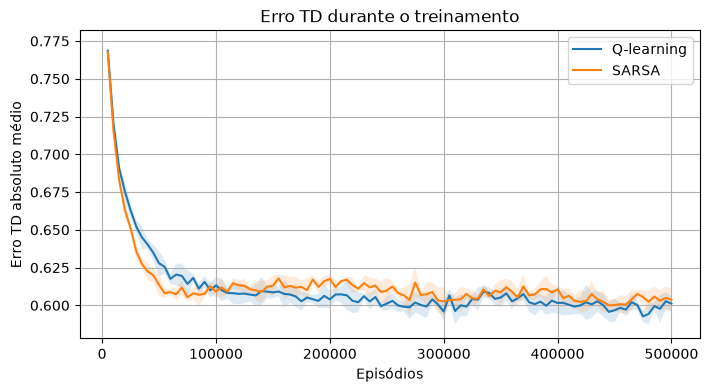

In [7]:
def aggregate_curve(results, algorithm, metric):
    curves = [
        block_mean(result[metric], BLOCK_SIZE)
        for result in results
        if result["algorithm"] == algorithm
    ]

    curves = np.vstack(curves)
    return np.mean(curves, axis=0), np.std(curves, axis=0)


block_x = np.arange(BLOCK_SIZE, N_EPISODES + 1, BLOCK_SIZE)

for metric, ylabel, title in [
    ("rewards", "Recompensa média", "Recompensa durante o treinamento"),
    ("lengths", "Comprimento médio", "Comprimento dos episódios"),
    ("td_errors", "Erro TD absoluto médio", "Erro TD durante o treinamento"),
]:
    plt.figure(figsize=(8, 4))

    for algorithm in ["Q-learning", "SARSA"]:
        mean_curve, std_curve = aggregate_curve(
            main_results, algorithm, metric
        )

        plt.plot(block_x, mean_curve, label=algorithm)
        plt.fill_between(
            block_x,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.15
        )

    plt.xlabel("Episódios")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


### 9.2 Avaliação final das políticas gulosas


In [8]:
rows = []

for algorithm in ["Q-learning", "SARSA"]:
    subset = [r for r in main_results if r["algorithm"] == algorithm]

    rows.append({
        "Algoritmo": algorithm,
        "Recompensa média": np.mean([r["evaluation"]["mean_reward"] for r in subset]),
        "DP recompensa": np.std([r["evaluation"]["mean_reward"] for r in subset]),
        "Taxa de vitória": np.mean([r["evaluation"]["win_rate"] for r in subset]),
        "Taxa de empate": np.mean([r["evaluation"]["draw_rate"] for r in subset]),
        "Taxa de derrota": np.mean([r["evaluation"]["loss_rate"] for r in subset]),
        "Passos médios": np.mean([r["evaluation"]["mean_length"] for r in subset]),
    })

main_summary_df = pd.DataFrame(rows)
main_summary_df


,Algoritmo,Recompensa média,DP recompensa,Taxa de vitória,Taxa de empate,Taxa de derrota,Passos médios
0,Q-learning,-0.05310,0.004505,0.42524,0.09642,0.47834,1.5814
1,SARSA,-0.05412,0.007450,0.42636,0.09316,0.48048,1.5521


## 10. Políticas e funções de valor

As tabelas $Q$ das cinco seeds são combinadas por média.

$$
\bar Q(s,a)=\frac{1}{N}\sum_i Q_i(s,a)
$$

A política agregada é:

$$
\pi(s)=\arg\max_a \bar Q(s,a)
$$

e:

$$
V(s)=\max_a \bar Q(s,a)
$$


In [9]:
PLAYER_SUMS = np.arange(12, 22)
DEALER_CARDS = np.arange(1, 11)


def aggregate_q_values(results, algorithm):
    subset = [r for r in results if r["algorithm"] == algorithm]
    states = set()

    for result in subset:
        states.update(result["q_values"].keys())

    mean_q = {}

    for state in states:
        values = [
            result["q_values"][state]
            for result in subset
            if state in result["q_values"]
        ]
        mean_q[state] = np.mean(np.vstack(values), axis=0)

    return mean_q


mean_q_learning = aggregate_q_values(main_results, "Q-learning")
mean_q_sarsa = aggregate_q_values(main_results, "SARSA")


def value_policy_matrices(q_values, usable_ace):
    V = np.full((10, 10), np.nan)
    policy = np.zeros((10, 10), dtype=int)

    for i, dealer in enumerate(DEALER_CARDS):
        for j, player_sum in enumerate(PLAYER_SUMS):
            state = (int(player_sum), int(dealer), bool(usable_ace))
            values = q_values.get(state, np.zeros(2))
            V[i, j] = np.max(values)
            policy[i, j] = np.argmax(values)

    return V, policy


def plot_value_and_policy(q_values, algorithm, usable_ace):
    V, policy = value_policy_matrices(q_values, usable_ace)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        V, ax=axes[0], cmap="coolwarm", center=0,
        xticklabels=PLAYER_SUMS, yticklabels=DEALER_CARDS
    )

    axes[0].set_title(f"V(s) — {algorithm}")
    axes[0].set_xlabel("Soma do jogador")
    axes[0].set_ylabel("Carta visível do dealer")

    labels = np.where(policy == 1, "H", "S")

    sns.heatmap(
        policy, ax=axes[1], annot=labels, fmt="",
        cmap="Accent_r", cbar=False,
        xticklabels=PLAYER_SUMS, yticklabels=DEALER_CARDS
    )

    axes[1].set_title(f"Política — {algorithm}")
    axes[1].set_xlabel("Soma do jogador")
    axes[1].set_ylabel("Carta visível do dealer")

    ace_text = "com ás utilizável" if usable_ace else "sem ás utilizável"
    fig.suptitle(f"{algorithm} — {ace_text}")

    plt.tight_layout()
    plt.show()


### 10.1 Q-learning


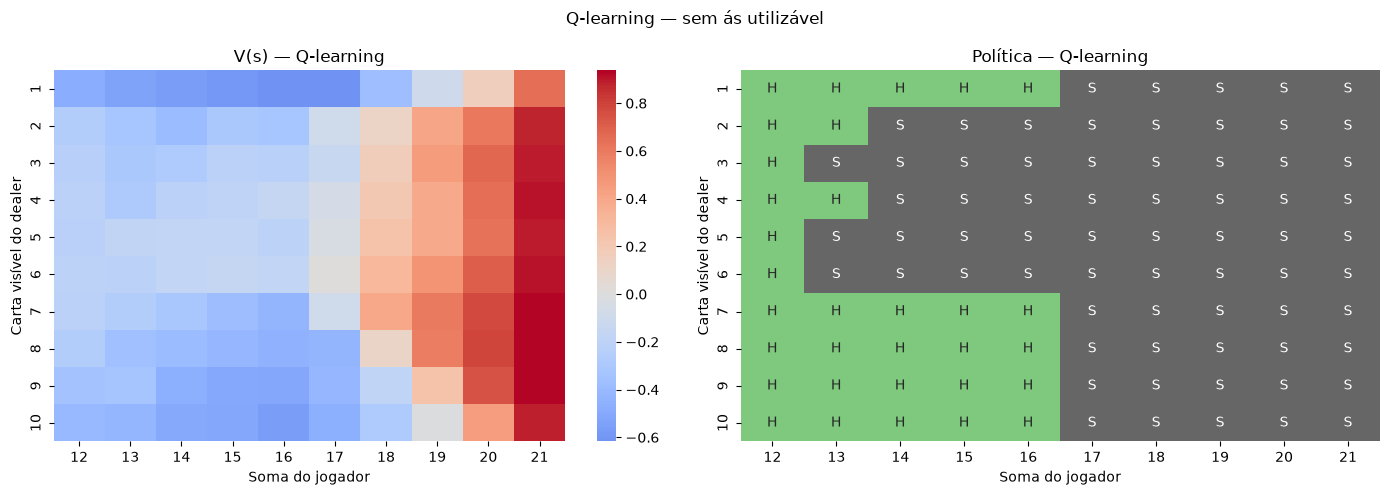

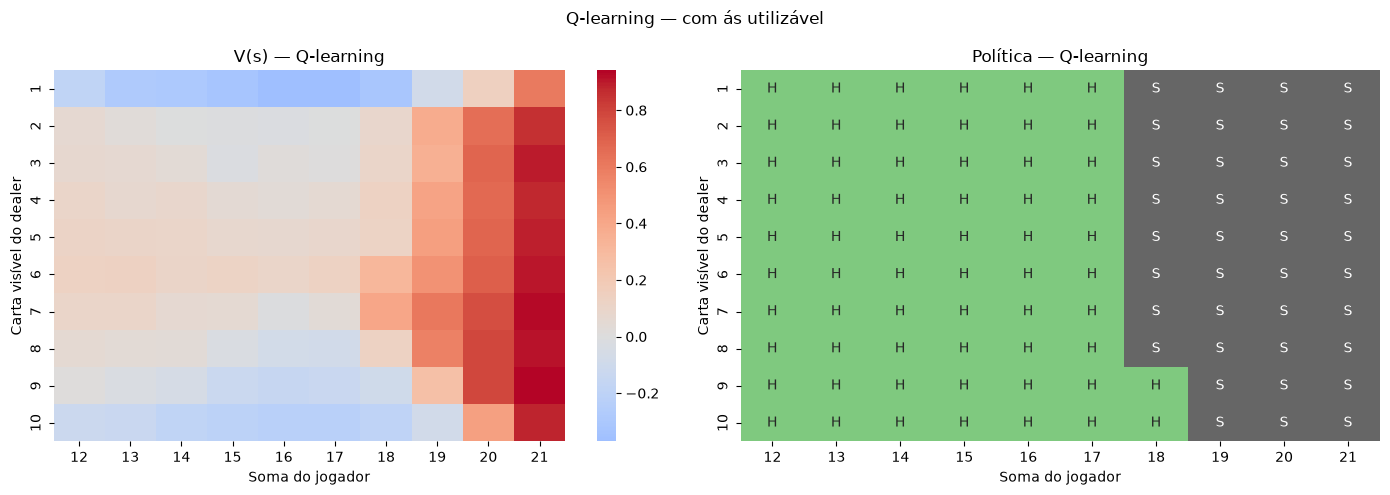

In [10]:
plot_value_and_policy(mean_q_learning, "Q-learning", usable_ace=False)
plot_value_and_policy(mean_q_learning, "Q-learning", usable_ace=True)


### 10.2 SARSA


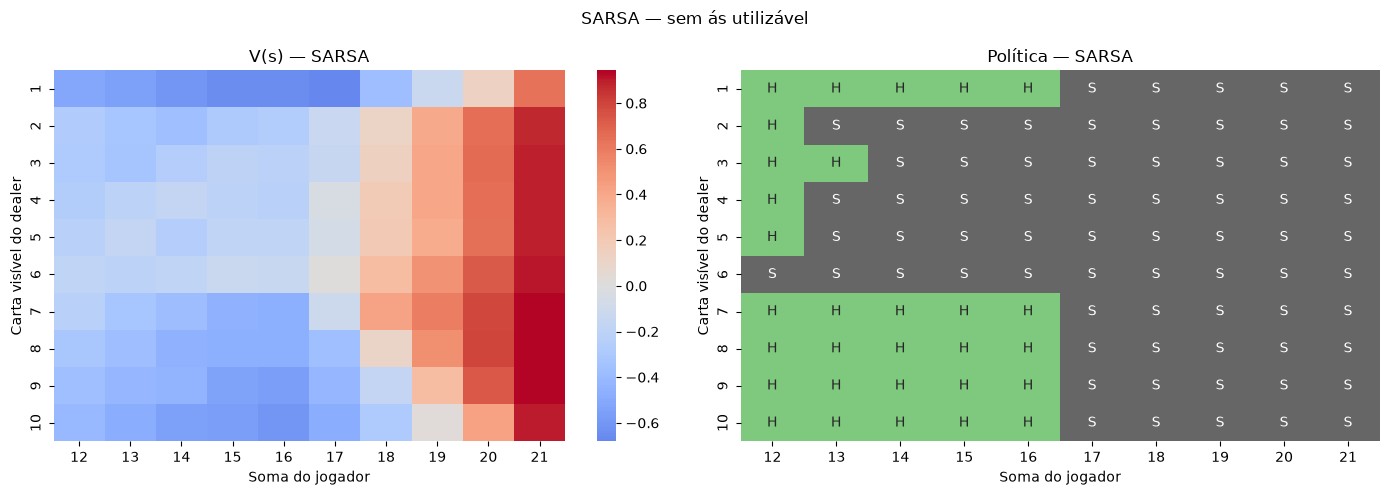

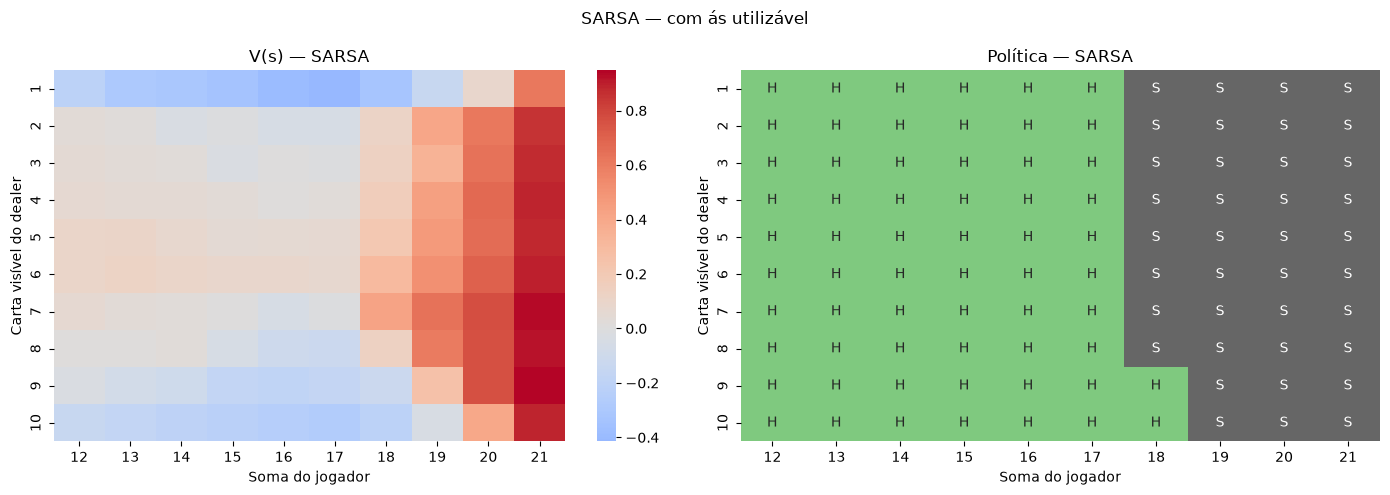

In [11]:
plot_value_and_policy(mean_q_sarsa, "SARSA", usable_ace=False)
plot_value_and_policy(mean_q_sarsa, "SARSA", usable_ace=True)


### 10.3 Estados em que as políticas divergem


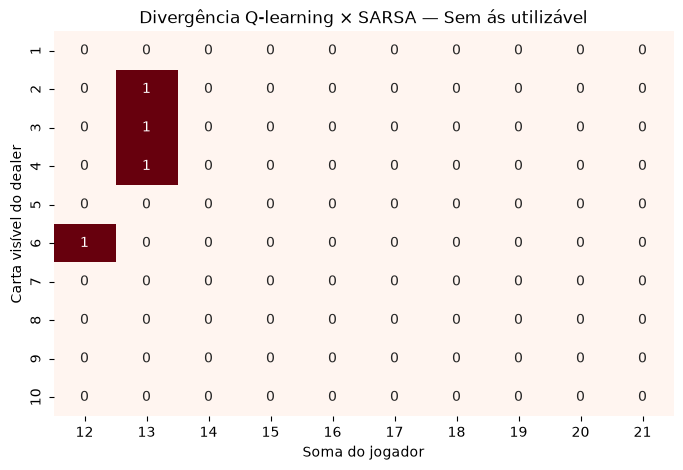

Sem ás utilizável — estados divergentes: 4


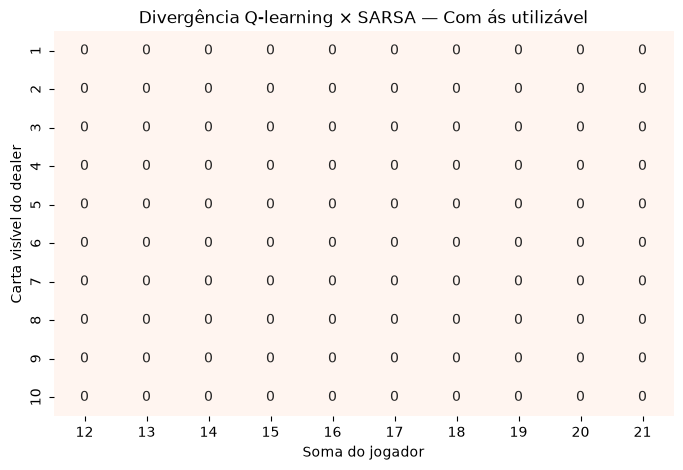

Com ás utilizável — estados divergentes: 0


In [12]:
def disagreement_matrix(q_a, q_b, usable_ace):
    matrix = np.zeros((10, 10), dtype=int)

    for i, dealer in enumerate(DEALER_CARDS):
        for j, player_sum in enumerate(PLAYER_SUMS):
            state = (int(player_sum), int(dealer), bool(usable_ace))

            a = int(np.argmax(q_a.get(state, np.zeros(2))))
            b = int(np.argmax(q_b.get(state, np.zeros(2))))

            matrix[i, j] = int(a != b)

    return matrix


for usable_ace, title in [
    (False, "Sem ás utilizável"),
    (True, "Com ás utilizável"),
]:
    matrix = disagreement_matrix(
        mean_q_learning,
        mean_q_sarsa,
        usable_ace
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Reds",
        cbar=False,
        xticklabels=PLAYER_SUMS,
        yticklabels=DEALER_CARDS
    )

    plt.title(f"Divergência Q-learning × SARSA — {title}")
    plt.xlabel("Soma do jogador")
    plt.ylabel("Carta visível do dealer")
    plt.show()

    print(title, "— estados divergentes:", int(np.sum(matrix)))


## 11. Experimento B — efeito da taxa de aprendizado

Serão testados:

$$
\alpha \in \{0.001,\ 0.01,\ 0.1\}
$$

Todos com 500.000 episódios e cinco seeds.

Os resultados de $\alpha=0.01$ já produzidos no Experimento A serão reutilizados.


In [13]:
alpha_results = list(main_results)

for alpha in [a for a in LEARNING_RATES if not np.isclose(a, LEARNING_RATE)]:
    for algorithm in ["Q-learning", "SARSA"]:
        for seed in SEEDS:
            print(f"Treinando {algorithm} — alpha={alpha} — seed={seed}")

            result = train_agent(
                algorithm=algorithm,
                num_episodes=N_EPISODES,
                learning_rate=alpha,
                gamma=GAMMA,
                start_epsilon=START_EPSILON,
                final_epsilon=FINAL_EPSILON,
                epsilon_decay=EPSILON_DECAY,
                seed=seed
            )

            result["evaluation"] = evaluate_q_table(
                result["q_values"],
                episodes=EVAL_EPISODES,
                seed=200_000 + seed
            )

            alpha_results.append(result)

print("Experimento B concluído.")


Treinando Q-learning — alpha=0.001 — seed=42
Treinando Q-learning — alpha=0.001 — seed=43
Treinando Q-learning — alpha=0.001 — seed=44
Treinando Q-learning — alpha=0.001 — seed=45
Treinando Q-learning — alpha=0.001 — seed=46
Treinando SARSA — alpha=0.001 — seed=42
Treinando SARSA — alpha=0.001 — seed=43
Treinando SARSA — alpha=0.001 — seed=44
Treinando SARSA — alpha=0.001 — seed=45
Treinando SARSA — alpha=0.001 — seed=46
Treinando Q-learning — alpha=0.1 — seed=42
Treinando Q-learning — alpha=0.1 — seed=43
Treinando Q-learning — alpha=0.1 — seed=44
Treinando Q-learning — alpha=0.1 — seed=45
Treinando Q-learning — alpha=0.1 — seed=46
Treinando SARSA — alpha=0.1 — seed=42
Treinando SARSA — alpha=0.1 — seed=43
Treinando SARSA — alpha=0.1 — seed=44
Treinando SARSA — alpha=0.1 — seed=45
Treinando SARSA — alpha=0.1 — seed=46
Experimento B concluído.


### 11.1 Tabela comparativa


In [14]:
rows = []

for algorithm in ["Q-learning", "SARSA"]:
    for alpha in LEARNING_RATES:
        subset = [
            r for r in alpha_results
            if r["algorithm"] == algorithm
            and np.isclose(r["learning_rate"], alpha)
        ]

        rows.append({
            "Algoritmo": algorithm,
            "Alpha": alpha,
            "Recompensa média": np.mean([r["evaluation"]["mean_reward"] for r in subset]),
            "DP recompensa": np.std([r["evaluation"]["mean_reward"] for r in subset]),
            "Taxa de vitória": np.mean([r["evaluation"]["win_rate"] for r in subset]),
            "Taxa de derrota": np.mean([r["evaluation"]["loss_rate"] for r in subset]),
        })

alpha_summary_df = pd.DataFrame(rows)
alpha_summary_df


,Algoritmo,Alpha,Recompensa média,DP recompensa,Taxa de vitória,Taxa de derrota
0,Q-learning,0.001,-0.05608,0.004828,0.42614,0.48222
1,Q-learning,0.010,-0.05310,0.004505,0.42524,0.47834
2,Q-learning,0.100,-0.06106,0.003219,0.42260,0.48366
3,SARSA,0.001,-0.05390,0.009637,0.42834,0.48224
4,SARSA,0.010,-0.05412,0.007450,0.42636,0.48048
5,SARSA,0.100,-0.06866,0.005517,0.41880,0.48746


### 11.2 Recompensa final em função de alpha


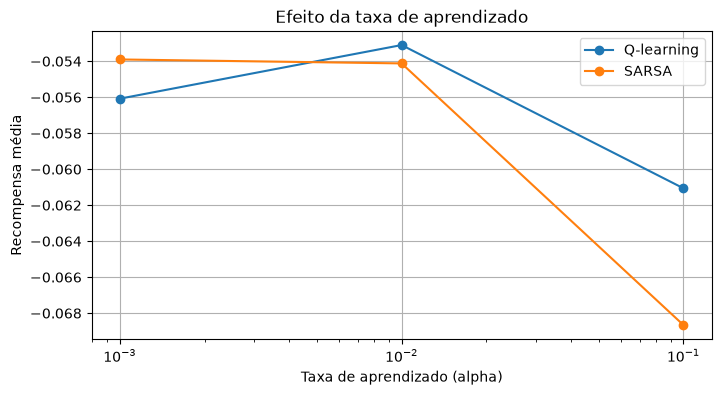

In [15]:
plt.figure(figsize=(8, 4))

for algorithm in ["Q-learning", "SARSA"]:
    subset = alpha_summary_df[
        alpha_summary_df["Algoritmo"] == algorithm
    ]

    plt.plot(
        subset["Alpha"],
        subset["Recompensa média"],
        marker="o",
        label=algorithm
    )

plt.xscale("log")
plt.xlabel("Taxa de aprendizado (alpha)")
plt.ylabel("Recompensa média")
plt.title("Efeito da taxa de aprendizado")
plt.legend()
plt.grid(True)
plt.show()


### 11.3 Curvas de aprendizado para diferentes valores de alpha


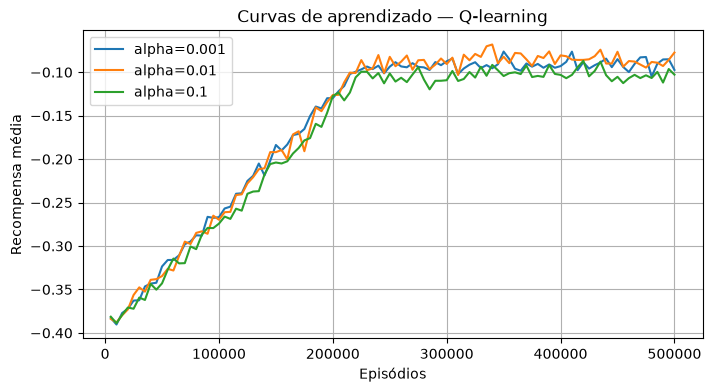

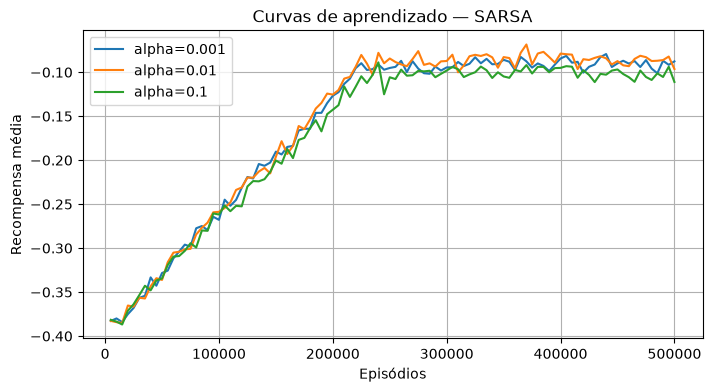

In [16]:
for algorithm in ["Q-learning", "SARSA"]:
    plt.figure(figsize=(8, 4))

    for alpha in LEARNING_RATES:
        subset = [
            r for r in alpha_results
            if r["algorithm"] == algorithm
            and np.isclose(r["learning_rate"], alpha)
        ]

        curves = np.vstack([
            block_mean(r["rewards"], BLOCK_SIZE)
            for r in subset
        ])

        plt.plot(
            block_x,
            np.mean(curves, axis=0),
            label=f"alpha={alpha}"
        )

    plt.xlabel("Episódios")
    plt.ylabel("Recompensa média")
    plt.title(f"Curvas de aprendizado — {algorithm}")
    plt.legend()
    plt.grid(True)
    plt.show()


## 12. Comparação com Monte Carlo Control

Como baseline do experimento anterior:

- recompensa média: `-0.0618`;
- taxa de vitória: `0.4263`;
- taxa de empate: `0.0856`;
- taxa de derrota: `0.4881`.

Esses valores são apenas reutilizados; Monte Carlo Control não é executado novamente neste notebook.


In [17]:
comparison_rows = [{
    "Método": "Monte Carlo Control",
    "Recompensa média": -0.0618,
    "Taxa de vitória": 0.4263,
    "Taxa de empate": 0.0856,
    "Taxa de derrota": 0.4881,
}]

for _, row in main_summary_df.iterrows():
    comparison_rows.append({
        "Método": row["Algoritmo"],
        "Recompensa média": row["Recompensa média"],
        "Taxa de vitória": row["Taxa de vitória"],
        "Taxa de empate": row["Taxa de empate"],
        "Taxa de derrota": row["Taxa de derrota"],
    })

mc_td_comparison_df = pd.DataFrame(comparison_rows)
mc_td_comparison_df


,Método,Recompensa média,Taxa de vitória,Taxa de empate,Taxa de derrota
0,Monte Carlo Control,-0.06180,0.42630,0.08560,0.48810
1,Q-learning,-0.05310,0.42524,0.09642,0.47834
2,SARSA,-0.05412,0.42636,0.09316,0.48048


## 13. Pontos para discussão

1. **Monte Carlo × TD**  
   Monte Carlo espera o episódio terminar; Q-learning e SARSA atualizam a cada transição.

2. **Q-learning × SARSA**  
   Q-learning usa $\max_a Q(S_{t+1},a)$; SARSA usa $Q(S_{t+1},A_{t+1})$.

3. **Off-policy × On-policy**  
   Q-learning aprende em direção à política gulosa enquanto explora; SARSA incorpora o comportamento exploratório em seu alvo.

4. **Curvas de recompensa**  
   Permitem comparar velocidade e estabilidade do aprendizado.

5. **Erro TD**  
   Mostra a magnitude das correções efetuadas ao longo do treinamento.

6. **Políticas aprendidas**  
   Os mapas permitem identificar estados em que os algoritmos tomam decisões diferentes.

7. **Taxa de aprendizado**  
   O experimento com $\alpha$ permite observar o equilíbrio entre velocidade de atualização e estabilidade.

8. **Variabilidade entre seeds**  
   Cinco repetições ajudam a separar diferenças consistentes de efeitos aleatórios.

9. **Comparação com Monte Carlo Control**  
   O mesmo Blackjack permite comparar diretamente aprendizado por retorno completo e bootstrapping.


## 14. Conclusões

Preencher após a execução, considerando:

- qual algoritmo apresentou maior recompensa média;
- se as políticas finais foram semelhantes;
- onde Q-learning e SARSA divergiram;
- qual $\alpha$ apresentou melhor equilíbrio entre desempenho e estabilidade;
- como TD se comparou ao Monte Carlo Control.


## 15. Correspondência com o relatório

| Seção do relatório | Evidência deste notebook |
|---|---|
| Introdução | objetivo e hipóteses da comparação |
| Fundamentação Teórica | TD, bootstrapping, Q-learning, SARSA, on-policy e off-policy |
| Ambiente | Blackjack-v1, estados, ações, recompensas e término |
| Metodologia | 500.000 episódios, cinco seeds, alpha, gamma, epsilon e avaliação gulosa |
| Treinamento e avaliação | atualizações TD por transição e avaliação sem exploração |
| Resultados | curvas de recompensa, comprimento, erro TD, tabelas e políticas |
| Resultados — hiperparâmetros | efeito de alpha |
| Resultados — políticas | mapas de V, Hit/Stick e divergência Q-learning × SARSA |
| Discussão | diferenças algorítmicas, exploração, bootstrapping e estabilidade |
| Conclusões | síntese comparativa entre Q-learning, SARSA e Monte Carlo Control |
